# 06 - Impact Analysis and Visualizations

External-data impact analysis, persona distributions, heatmaps, clustered zones, KDE plots, and interactive maps.


**Impact of External Data on Persona Scores:**

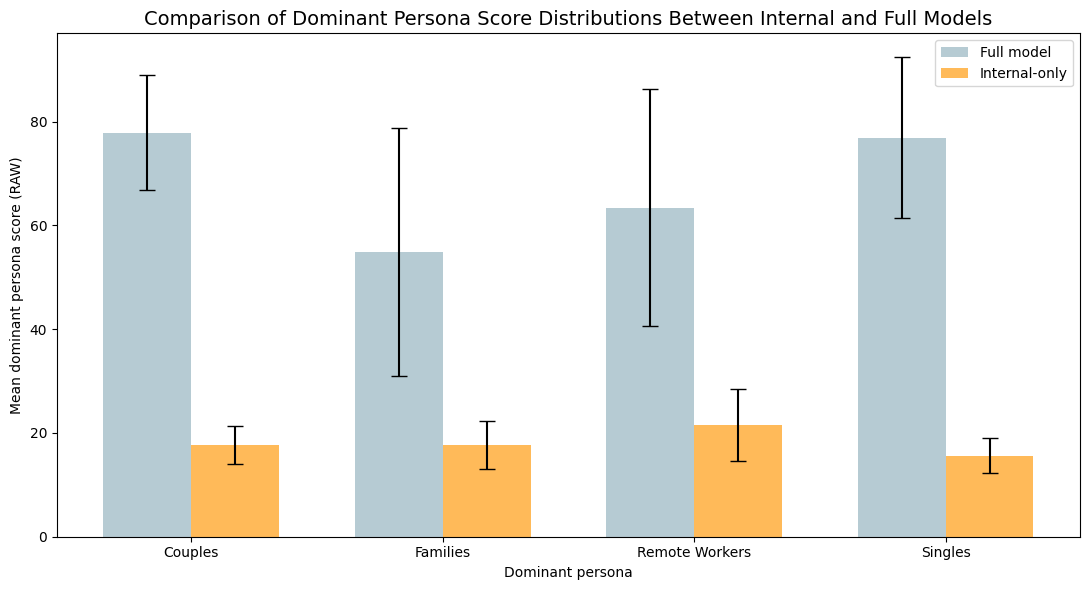

In [0]:
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# Input tables 
df_full     = final_display              # Internal + External data
df_internal = final_display_internal     # Internal

# Compute PERSONA SCORE STATS (RAW, dominant)
def compute_stats(df, label):
    return (
        df
        .selectExpr(
            "dominant_persona",
            "greatest(score_singles_raw, score_couples_raw, score_families_raw, score_work_raw) as dominant_score"
        )
        .groupBy("dominant_persona")
        .agg(
            F.avg("dominant_score").alias("mean"),
            F.stddev("dominant_score").alias("stddev"),
            F.variance("dominant_score").alias("variance")
        )
        .withColumn("model", F.lit(label))
    )

stats_full     = compute_stats(df_full, "Full model")
stats_internal = compute_stats(df_internal, "Internal-only")

stats = stats_full.unionByName(stats_internal).collect()

# Organize data for plotting
personas = sorted({r["dominant_persona"] for r in stats})
models   = ["Full model", "Internal-only"]

mean_map = {(r["dominant_persona"], r["model"]): r["mean"] for r in stats}
std_map  = {(r["dominant_persona"], r["model"]): r["stddev"] for r in stats}

colors = {
    "Full model": "#AEC6CF",        # pastel blue
    "Internal-only": "#FFB347",     # pastel orange
}

# Plot: mean ± stddev
x = range(len(personas))
width = 0.35

plt.figure(figsize=(11, 6))

for i, model in enumerate(models):
    means = [mean_map[(p, model)] for p in personas]
    stds  = [std_map[(p, model)] for p in personas]

    plt.bar(
        [v + (i - 0.5) * width for v in x],
        means,
        width=width,
        yerr=stds,
        capsize=6,
        label=model,
        color=colors[model],
        alpha=0.9
    )

plt.xticks(x, personas)
plt.ylabel("Mean dominant persona score (RAW)")
plt.xlabel("Dominant persona")
plt.title(
    "Comparison of Dominant Persona Score Distributions Between Internal and Full Models",
    fontsize=14
)
plt.legend()
plt.tight_layout()
plt.show()  

**Distribution of dominant persona over assets:**

Total Listings Analyzed: 14363
Distribution Table:
  dominant_persona  count  percentage
0         Families   4834   33.655921
1          Singles   3657   25.461255
2   Remote Workers   3336   23.226345
3          Couples   2536   17.656478


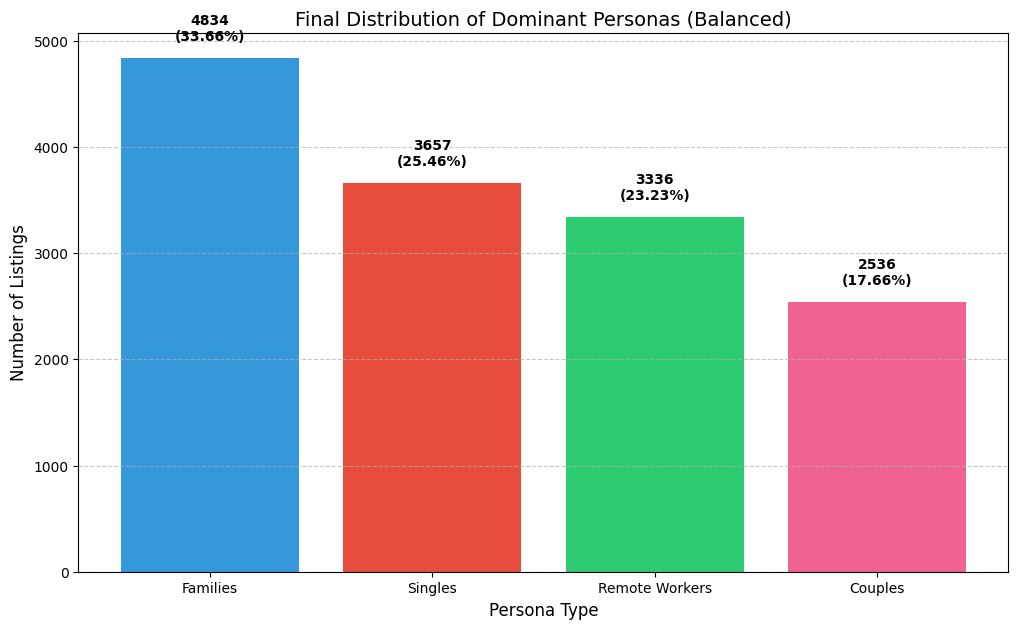

Cleanup complete.


In [0]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F

# 1. The efficient step: just one fetch from Spark (single job)
# We just count by groups and pass immediately to Pandas
# The result is a tiny 4-row table, so it's very fast
pdf_dist = final_display.groupBy('dominant_persona').count().toPandas()

# 2. Calculations in Python/Pandas (a thousand times faster than running another query in Spark)
total_count = pdf_dist['count'].sum()
pdf_dist['percentage'] = (pdf_dist['count'] / total_count) * 100
pdf_dist = pdf_dist.sort_values('count', ascending=False).reset_index(drop=True)

print(f"Total Listings Analyzed: {total_count}")
print("Distribution Table:")
print(pdf_dist)

#3. Creating the graph (remains almost the same)
plt.figure(figsize=(12, 7))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f06292'] 
bars = plt.bar(pdf_dist['dominant_persona'], pdf_dist['count'], color=colors)

for i, bar in enumerate(bars):
    yval = bar.get_height()
    # Using iloc to access data safely in Pandas
    percentage = round(pdf_dist.iloc[i]['percentage'], 2)
    plt.text(bar.get_x() + bar.get_width()/2, yval + (total_count*0.01), 
             f'{int(yval)}\n({percentage}%)', 
             va='bottom', ha='center', fontweight='bold')

plt.title('Final Distribution of Dominant Personas (Balanced)', fontsize=14)
plt.xlabel('Persona Type', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Cleaning
nearby_stats.unpersist()
places_clean_df.unpersist()

print("Cleanup complete.")

In [0]:
%pip install folium

  Obtaining dependency information for folium from https://files.pythonhosted.org/packages/b5/a8/5f764f333204db0390362a4356d03a43626997f26818a0e9396f1b3bd8c9/folium-0.20.0-py2.py3-none-any.whl.metadata
  Obtaining dependency information for branca>=0.6.0 from https://files.pythonhosted.org/packages/7e/50/fc9680058e63161f2f63165b84c957a0df1415431104c408e8104a3a18ef/branca-0.8.2-py3-none-any.whl.metadata
  Obtaining dependency information for xyzservices from https://files.pythonhosted.org/packages/ef/5c/2c189d18d495dd0fa3f27ccc60762bbc787eed95b9b0147266e72bb76585/xyzservices-2025.11.0-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/113.4 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/93.9 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.9/93.9 kB 10.2 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.r

**Persona Dominance Heatmap by City:**

In [0]:
import folium
from folium.plugins import HeatMap
import pandas as pd

#1. Preparing the data
pdf = final_display.toPandas()

# 2. Settings (Cities and Colors)
city_centers = {
    "Barcelona": [41.3851, 2.1734], "Budapest": [47.4979, 19.0402],
    "Buenos Aires": [-34.6037, -58.3816], "Cape Town": [-33.9249, 18.4241],
    "Lisbon": [38.7223, -9.1393], "Mexico City": [19.4326, -99.1332],
    "Miami": [25.7617, -80.1918], "New York": [40.7128, -74.0060],
    "Paris": [48.8566, 2.3522], "Phuket": [7.8804, 98.3923],
    "San Francisco": [37.7749, -122.4194], "Sao Paulo": [-23.5505, -46.6333],
    "Tel Aviv": [32.0853, 34.7818], "Tiberias": [32.7940, 35.5312],
    "Tokyo": [35.6762, 139.6503]
}

# Color settings for heatmaps (gradients)
heat_layers = {
    'Singles': {
        'gradient': {0.4: '#ff8a80', 0.65: '#ff5252', 1.0: '#d50000'}, # red
        'name': "<span style='color:#d50000; font-weight:bold;'>●</span> Singles"
    },
    'Couples': {
        'gradient': {0.4: '#f48fb1', 0.65: '#ec407a', 1.0: '#880e4f'}, # pink
        'name': "<span style='color:#880e4f; font-weight:bold;'>●</span> Couples"
    },
    'Families': {
        'gradient': {0.4: '#81d4fa', 0.65: '#29b6f6', 1.0: '#01579b'}, # blue
        'name': "<span style='color:#01579b; font-weight:bold;'>●</span> Families"
    },
    'Remote Workers': {
        'gradient': {0.4: '#a5d6a7', 0.65: '#66bb6a', 1.0: '#1b5e20'}, # green
        'name': "<span style='color:#1b5e20; font-weight:bold;'>●</span> Remote Workers"
    }
}

# 3. Creating the map (OpenStreetMap for maximum detail)
m = folium.Map(location=[48.8566, 2.3522], zoom_start=4, tiles='OpenStreetMap')

# 3. Creating the map (OpenStreetMap for maximum detail)
for persona, config in heat_layers.items():
    # Filter the data by the current persona
    data = pdf[pdf['dominant_persona'] == persona][['lat', 'long']].values.tolist()
    
    # Add to map
    HeatMap(
        data,
        name=config['name'],
        min_opacity=0.4,
        radius=18,     
        blur=12,      
        gradient=config['gradient'],
        overlay=True,
        control=True
    ).add_to(m)

#5. Component 1: Removable Persona Filter (LayerControl) 
folium.LayerControl(position='topright', collapsed=True).add_to(m)

#6. Component 2: Removable Cities Menu (Custom HTML)
map_name = m.get_name()
city_buttons_html = "".join([
    f'<div class="city-item" onclick="{map_name}.flyTo({coords}, 13)">{city}</div>'
    for city, coords in sorted(city_centers.items())
])

custom_ui = f"""
<style>
    /* The design of the cities' pull-out button - exactly the same as your code */
    #city-menu-container {{
        position: fixed;
        top: 10px;
        right: 60px; /* Located to the left of the layers button */
        z-index: 1000;
        font-family: 'Segoe UI', sans-serif;
    }}

    /* The round button */
    .menu-button {{
        width: 44px;
        height: 44px;
        background: white;
        border-radius: 4px;
        box-shadow: 0 1px 5px rgba(0,0,0,0.4);
        display: flex;
        align-items: center;
        justify-content: center;
        font-size: 20px;
        cursor: pointer;
        transition: 0.3s;
    }}
    
    .menu-button:hover {{ background: #f4f4f4; }}

    /* The list itself */
    .city-list {{
        display: none;
        position: absolute;
        top: 0;
        right: 50px;
        background: white;
        padding: 10px;
        border-radius: 8px;
        box-shadow: 0 2px 15px rgba(0,0,0,0.2);
        width: 140px;
        max-height: 400px;
        overflow-y: auto;
    }}

    /* Hover mechanism */
    #city-menu-container:hover .city-list {{
        display: block;
    }}

    /* Design the items */
    .city-item {{
        padding: 8px;
        border-bottom: 1px solid #eee;
        cursor: pointer;
        font-size: 13px;
        color: #333;
    }}
    .city-item:hover {{
        background-color: #f0f7ff;
        color: #3498db;
        font-weight: bold;
        border-radius: 4px;
    }}
    .city-item:last-child {{ border-bottom: none; }}
    
    .list-title {{
        font-weight: bold; 
        margin-bottom: 8px; 
        border-bottom: 2px solid #3498db; 
        padding-bottom: 5px;
        font-size: 12px;
        color: #2c3e50;
    }}
</style>

<div id="city-menu-container">
    <div class="menu-button">🌍</div>
    <div class="city-list">
        <div class="list-title">JUMP TO CITY</div>
        {city_buttons_html}
    </div>
</div>
"""

m.get_root().html.add_child(folium.Element(custom_ui))

display(m)

**Persona Zones Map (Clustering + Convex Hull):**

In [0]:
import warnings
import os
import logging
import sys
import contextlib
import io

# 1) GLOBAL SETTINGS (silence warnings & noisy logs)
# Silence Python warnings
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")

# Silence Spark / py4j chatter
logging.getLogger("py4j").setLevel(logging.ERROR)

# Utility: temporarily suppress stderr (where threadpoolctl prints its noise)
@contextlib.contextmanager
def suppress_stderr():
    """Temporarily suppress stderr output (e.g., noisy native library traces)."""
    old_stderr = sys.stderr
    try:
        sys.stderr = io.StringIO()
        yield
    finally:
        sys.stderr = old_stderr


import folium
from folium.plugins import MarkerCluster
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from sklearn.cluster import KMeans

# 2) Data preparation 
pdf = final_display.toPandas()

persona_colors = {
    "Singles": "#e74c3c",
    "Couples": "#f06292",
    "Families": "#3498db",
    "Remote Workers": "#2ecc71"
}

city_centers = {
    "Barcelona": [41.3851, 2.1734], "Budapest": [47.4979, 19.0402],
    "Buenos Aires": [-34.6037, -58.3816], "Cape Town": [-33.9249, 18.4241],
    "Lisbon": [38.7223, -9.1393], "Mexico City": [19.4326, -99.1332],
    "Miami": [25.7617, -80.1918], "New York": [40.7128, -74.0060],
    "Paris": [48.8566, 2.3522], "Phuket": [7.8804, 98.3923],
    "San Francisco": [37.7749, -122.4194], "Sao Paulo": [-23.5505, -46.6333],
    "Tel Aviv": [32.0853, 34.7818], "Tiberias": [32.7940, 35.5312],
    "Tokyo": [35.6762, 139.6503]
}

data_cities = pdf["source_city"].dropna().unique()

# 3) Create map + Dynamic clustering
m = folium.Map(location=[48.8566, 2.3522], zoom_start=2, tiles="OpenStreetMap")

# If you later want point clustering too, keep MarkerCluster
# Here you're drawing polygons, so MarkerCluster isn't required.
# Still leaving it out to keep the map lighter.

for city in data_cities:
    city_data = pdf[pdf["source_city"] == city].copy()
    num_listings = len(city_data)

    if num_listings < 5:
        continue

    # Dynamic cluster sizing:
    # 1 cluster per ~50 listings (clamped)
    calculated_clusters = int(num_listings / 50)
    n_clusters = max(5, min(40, calculated_clusters))

    # Protection for small datasets
    if num_listings < n_clusters * 2:
        n_clusters = max(2, int(num_listings / 3))

    # Safety: if still too small for KMeans
    if n_clusters < 2 or num_listings < n_clusters:
        continue

    try:
        # Silence threadpoolctl tracebacks that print to stderr during fit_predict
        with suppress_stderr():
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            city_data["local_cluster"] = kmeans.fit_predict(city_data[["lat", "long"]])

        for cluster_id in range(n_clusters):
            cluster_points = city_data[city_data["local_cluster"] == cluster_id]

            # Need at least 3 unique points for a polygon
            if len(cluster_points[["lat", "long"]].drop_duplicates()) < 3:
                continue

            dominant = cluster_points["dominant_persona"].value_counts().idxmax()
            color = persona_colors.get(dominant, "gray")
            points = cluster_points[["lat", "long"]].values

            try:
                hull = ConvexHull(points, qhull_options="QJ")
                hull_path = points[hull.vertices].tolist()

                folium.Polygon(
                    locations=hull_path,
                    color=color,
                    fill=True,
                    fill_color=color,
                    fill_opacity=0.4,
                    weight=1,
                    popup=folium.Popup(
                        f"<b>{city}</b><br>Zone {cluster_id + 1}<br>{dominant}",
                        max_width=200
                    )
                ).add_to(m)

            except Exception:
                # If hull fails for numerical reasons, skip this cluster
                continue

    except Exception:
        # If clustering fails for any reason, skip city
        continue

# 4) UI: City nav + Legend
map_name = m.get_name()
city_buttons = ""
for city_name in sorted(city_centers.keys()):
    coords = city_centers[city_name]
    city_buttons += f'<button class="city-btn" onclick="{map_name}.flyTo({coords}, 14)">{city_name}</button>'

custom_ui = f"""
<style>
    /* Cities bar */
    #city-nav {{ position: fixed; top: 20px; right: 0; z-index: 9999; display: flex; transform: translateX(180px); transition: 0.3s; }}
    #city-nav:hover {{ transform: translateX(0); }}
    .nav-tag {{ width: 50px; height: 50px; background: #2c3e50; color: white; border-radius: 10px 0 0 10px; display: flex; align-items: center; justify-content: center; cursor: pointer; font-size: 24px; box-shadow: -2px 2px 5px rgba(0,0,0,0.2); }}
    .city-list {{ width: 180px; background: white; padding: 12px; box-shadow: -4px 0 15px rgba(0,0,0,0.2); max-height: 500px; overflow-y: auto; border-bottom-left-radius: 10px; }}
    .city-btn {{ display: block; width: 100%; padding: 10px; margin-bottom: 6px; background: #f8f9fa; border: 1px solid #ddd; border-radius: 6px; cursor: pointer; text-align: left; font-size: 13px; font-weight: 500; transition: 0.2s; }}
    .city-btn:hover {{ background: #e9ecef; border-left: 5px solid #3498db; }}

    /* Legend */
    #legend {{ position: fixed; bottom: 30px; left: 20px; width: 170px; background: rgba(255, 255, 255, 0.95); padding: 15px; border-radius: 10px; box-shadow: 0 0 20px rgba(0,0,0,0.15); z-index: 9999; font-family: 'Segoe UI', sans-serif; }}
    .legend-item {{ margin-bottom: 8px; font-size: 13px; display: flex; align-items: center; color: #333; }}
    .color-box {{ width: 16px; height: 16px; margin-right: 10px; border-radius: 4px; opacity: 0.8; }}
</style>

<div id="city-nav">
    <div class="nav-tag">🗺️</div>
    <div class="city-list">
        <div style="margin-bottom:10px; font-weight:bold; color:#2c3e50; border-bottom:2px solid #3498db; padding-bottom:5px;">
            Select City (Zoom In)
        </div>
        {city_buttons}
    </div>
</div>

<div id="legend">
    <div style="font-weight:bold; margin-bottom:10px; border-bottom:1px solid #eee; font-size:14px;">
        Dominant Persona
    </div>
    <div class="legend-item"><div class="color-box" style="background:#e74c3c;"></div>Singles</div>
    <div class="legend-item"><div class="color-box" style="background:#f06292;"></div>Couples</div>
    <div class="legend-item"><div class="color-box" style="background:#3498db;"></div>Families</div>
    <div class="legend-item"><div class="color-box" style="background:#2ecc71;"></div>Remote Workers</div>
</div>
"""

m.get_root().html.add_child(folium.Element(custom_ui))
display(m)


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run wistful-wasp-438 at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/3680157061074107/runs/8b2a910548f94531b55fca4591ce5992
🧪 View experiment at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/3680157061074107


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run rambunctious-bee-848 at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/3680157061074107/runs/0b5c08520c6c4689845f03ae40b9ad98
🧪 View experiment at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/3680157061074107


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

...

🏃 View run exultant-horse-106 at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/3680157061074107/runs/05e67e13532940729b46ca7af614cb1a
🧪 View experiment at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/3680157061074107


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run treasured-wasp-792 at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/3680157061074107/runs/8f91177e849141679e8e30eb66559088
🧪 View experiment at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/3680157061074107


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run defiant-goat-823 at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/3680157061074107/runs/caad6f7f7ef248f6bbcfa58480f2dfe7
🧪 View experiment at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/3680157061074107


**Persona Score Distributions (KDE):**

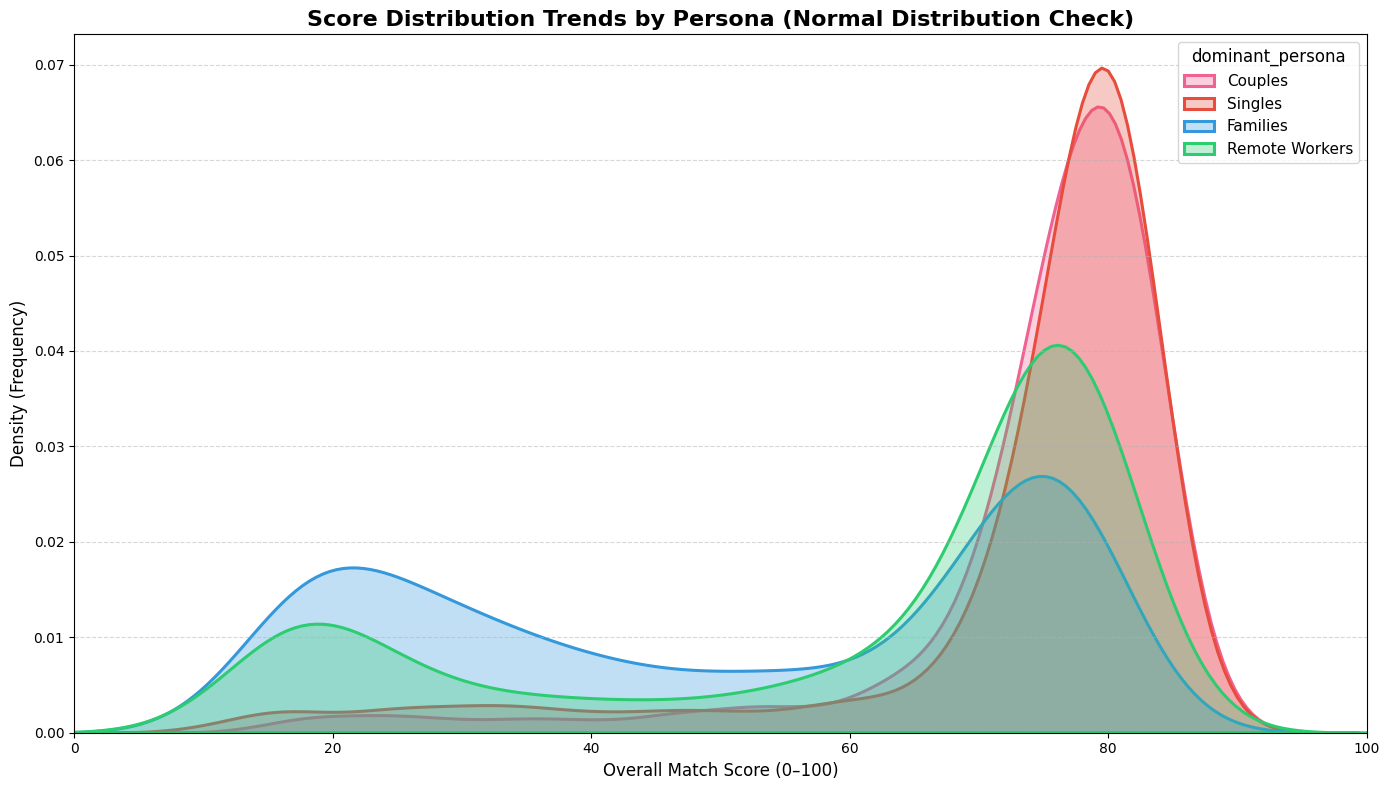

In [0]:
# 5) Score distribution plot — matched to reference figure
plt.figure(figsize=(14, 8))

persona_order = ["Couples", "Singles", "Families", "Remote Workers"]

for persona in persona_order:
    subset = pdf[pdf["dominant_persona"] == persona]

    if len(subset) < 10:
        continue

    sns.kdeplot(
        x=subset["overall_score"],
        fill=True,
        alpha=0.30,
        linewidth=2.2,
        color=persona_colors[persona],
        label=persona,
        bw_adjust=1.1,
        common_norm=False   
    )

plt.title(
    "Score Distribution Trends by Persona (Normal Distribution Check)",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Overall Match Score (0–100)", fontsize=12)
plt.ylabel("Density (Frequency)", fontsize=12)

plt.xlim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend(
    title="dominant_persona",
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout()
plt.show()


**Interactive Persona Map (Sampled Listings):**

In [0]:
import folium
from folium.plugins import MarkerCluster, FeatureGroupSubGroup
import pandas as pd

# 1. Data Preparation (Random Sample 80)
full_pdf = final_display.toPandas()

pdf = full_pdf.groupby('source_city').apply(
    lambda x: x.sample(n=min(len(x), 80), random_state=42)
).reset_index(drop=True)

# 2. Settings (Cities and Colors)
city_centers = {
    "Barcelona": [41.3851, 2.1734], "Budapest": [47.4979, 19.0402],
    "Buenos Aires": [-34.6037, -58.3816], "Cape Town": [-33.9249, 18.4241],
    "Lisbon": [38.7223, -9.1393], "Mexico City": [19.4326, -99.1332],
    "Miami": [25.7617, -80.1918], "New York": [40.7128, -74.0060],
    "Paris": [48.8566, 2.3522], "Phuket": [7.8804, 98.3923],
    "San Francisco": [37.7749, -122.4194], "Sao Paulo": [-23.5505, -46.6333],
    "Tel Aviv": [32.0853, 34.7818], "Tiberias": [32.7940, 35.5312],
    "Tokyo": [35.6762, 139.6503]
}

persona_colors = {
    'Singles': '#e74c3c',       # red
    'Couples': '#f06292',       # pink
    'Families': '#3498db',      # blue
    'Remote Workers': '#2ecc71' # green
}

# 3. Creating the map
# Changing the map name from cartodbpositron to something neutral ('Base Map') so that the strange name doesn't appear
m = folium.Map(location=[48.8566, 2.3522], zoom_start=4)
folium.TileLayer('CartoDB positron', name='Base Map').add_to(m)

# MarkerCluster
mcg = MarkerCluster(control=False, options={'disableClusteringAtZoom': 16}).add_to(m)

# Creating layers for the filter (with colored circles named)
groups = {}
for persona, color in persona_colors.items():
    # The name that will appear inside the pull-down bar
    group_name = f"<span style='color:{color}; font-size:14px;'>●</span> {persona}"
    groups[persona] = FeatureGroupSubGroup(mcg, name=group_name).add_to(m)

#4. Adding the dots
for _, row in pdf.iterrows():
    persona = row['dominant_persona']
    color = persona_colors.get(persona, 'gray')
    
    html = f"""
    <div style="font-family: 'Segoe UI', sans-serif; width: 260px;">
        <h4 style="margin: 0; color: #2c3e50; border-bottom: 2px solid {color}; padding-bottom: 5px;">
            {row['listing_name'][:30]}...
        </h4>
        <div style="margin-top: 10px; font-size: 13px;">
            <div style="display:flex; justify-content:space-between;"><span>❤️ Couples:</span><b>{row['score_couples']:.1f}</b></div>
            <div style="display:flex; justify-content:space-between;"><span>🍸 Singles:</span><b>{row['score_singles']:.1f}</b></div>
            <div style="display:flex; justify-content:space-between;"><span>👨‍👩‍👧 Families:</span><b>{row['score_families']:.1f}</b></div>
            <div style="display:flex; justify-content:space-between;"><span>💻 Remote:</span><b>{row['score_work']:.1f}</b></div>
        </div>
        <div style="background-color: #f8f9fa; padding: 5px; margin-top: 10px; text-align: center;">
            <span style="color: #7f8c8d; font-size: 11px;">Dominant Persona</span><br>
            <b style="color: {color}; font-size: 14px;">{persona.upper()}</b>
        </div>
        <a href="{row['url']}" target="_blank" style="display: block; margin-top: 12px; background-color: {color}; color: white; text-align: center; padding: 8px; text-decoration: none; border-radius: 4px; font-weight: bold; font-size: 12px;">View on Airbnb →</a>
    </div>
    """

    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=6, color=color, fill=True, fill_color=color, fill_opacity=0.8,
        popup=folium.Popup(html, max_width=300),
        tooltip=f"{persona}: {row['overall_score']:.1f}"
    ).add_to(groups[persona])

# 5. Component 1: Persona Filter (LayerControl)
# collapsed=True makes it an icon that only opens on hover
folium.LayerControl(position='topright', collapsed=True).add_to(m)

#6. Component 2: Removable Cities Menu (Custom HTML)
map_name = m.get_name()
city_buttons_html = "".join([
    f'<div class="city-item" onclick="{map_name}.flyTo({coords}, 13)">{city}</div>'
    for city, coords in sorted(city_centers.items())
])

custom_ui = f"""
<style>
    /* Design the removable button of the cities */
    #city-menu-container {{
        position: fixed;
        top: 10px;
        right: 60px; 
        z-index: 1000;
        font-family: 'Segoe UI', sans-serif;
    }}

    /* The round button you see at the beginning */
    .menu-button {{
        width: 44px;
        height: 44px;
        background: white;
        border-radius: 4px; 
        box-shadow: 0 1px 5px rgba(0,0,0,0.4);
        display: flex;
        align-items: center;
        justify-content: center;
        font-size: 20px;
        cursor: pointer;
        transition: 0.3s;
    }}
    
    .menu-button:hover {{ background: #f4f4f4; }}

    /* The list itself (hidden at first) */
    .city-list {{
        display: none;
        position: absolute;
        top: 0;
        right: 50px; 
        background: white;
        padding: 10px;
        border-radius: 8px;
        box-shadow: 0 2px 15px rgba(0,0,0,0.2);
        width: 140px;
        max-height: 400px;
        overflow-y: auto;
    }}

    /* Hover mechanism */
    #city-menu-container:hover .city-list {{
        display: block; 
    }}

    /* Format the items in the list */
    .city-item {{
        padding: 8px;
        border-bottom: 1px solid #eee;
        cursor: pointer;
        font-size: 13px;
        color: #333;
    }}
    .city-item:hover {{
        background-color: #f0f7ff;
        color: #3498db;
        font-weight: bold;
        border-radius: 4px;
    }}
    .city-item:last-child {{ border-bottom: none; }}
    
    .list-title {{
        font-weight: bold; 
        margin-bottom: 8px; 
        border-bottom: 2px solid #3498db; 
        padding-bottom: 5px;
        font-size: 12px;
        color: #2c3e50;
    }}
</style>

<div id="city-menu-container">
    <div class="menu-button">🌍</div>
    <div class="city-list">
        <div class="list-title">JUMP TO CITY</div>
        {city_buttons_html}
    </div>
</div>
"""

m.get_root().html.add_child(folium.Element(custom_ui))
display(m)

*Thank You (:*